In [1]:
import sys
sys.path.append("../..")
import torch
from torch.distributions import Normal
from sbi.inference import NPE_A
from sbi.analysis import pairplot
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


We hypothesize that SNPE-A will struggle to provide a good posterior approximation when the prior (or proposal) mass is far from the posterior mass. 

We can test this in 1D by considering the following example:

$$p(\theta) = N(\theta ; 0, 1)$$

$$p(x|\theta) = N(x; \theta , 1)$$

where we observe $x_\text{obs}\in \{0,1,2,3,...\}$ ($x_\text{obs}$ is $x_\text{obs}$ standard deviations above the mean of the prior). In this case, we have a posterior given analytically by

$$p(\theta|x_\text{obs}) = N\left(\theta; \frac{x_\text{obs}}{2}, \frac{1}{2}\right)$$

We expect that, for large enough $x$ (think over $\approx 4\sigma$ away from prior mean), the SNPE-A algorithm will struggle to approximate the true posterior, since it will be extrapolating past the $(x, \theta)$ training pairs. 

Note that the SNPE-A algorithm (and therefore the python implementation from `sbi`) only allows Gaussian or uniform priors.

In [2]:
from utils_1d_examples.gaussiangaussian_far import prior_pdf, likelihood_pdf, posterior_pdf, plot_approximate_posterior

# Amortized Inference with (S)NPE-A

In [3]:
# Define simulator
def model(mu):
    return mu + torch.randn_like(mu)

# Define prior
prior = torch.distributions.MultivariateNormal(torch.tensor([0.]), torch.tensor([[1.]]))


In [4]:
inference = NPE_A(prior=prior)  # (S)NPE-A algorithm (fast epsilon-free inference)
num_simulations = 20000  # number of (theta, x) pairs sampled and trained on
mu = prior.sample((num_simulations,))  # simulate parameters from prior
x = model(mu)  # simulate data for each parameter
inference = inference.append_simulations(mu, x)
density_estimator = inference.train()
posterior = inference.build_posterior()

def approximate_posterior(theta, x):
    """
    Output SNPE-A analytical posterior approximation \hat{p}(theta | x)

    theta and x must be 1D torch tensors
    """
    return torch.exp(posterior.potential(theta, x))

/Users/Lieve/Documents/Masters Project/sbi_venv/lib/python3.9/site-packages/torch/nn/init.py:582: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


 Neural network successfully converged after 26 epochs.

In [5]:
# Can plot histogram of samples OR analytical posterior approximation
# samples = posterior.sample((10000,), x=x_observed)

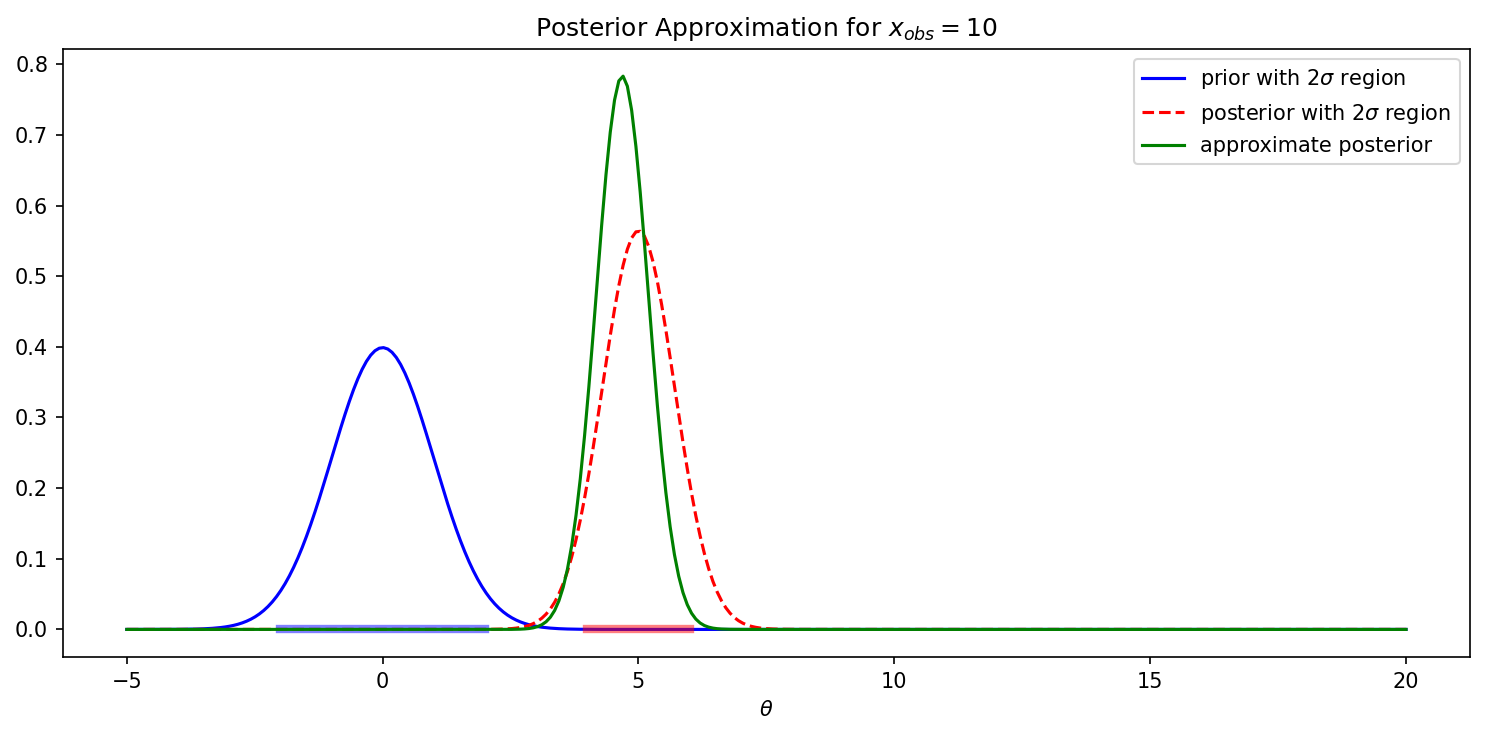

In [6]:
x_observed = 10 # Observed data
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed, title=r"Posterior Approximation for $x_{obs} = $" + f"{x_observed}")

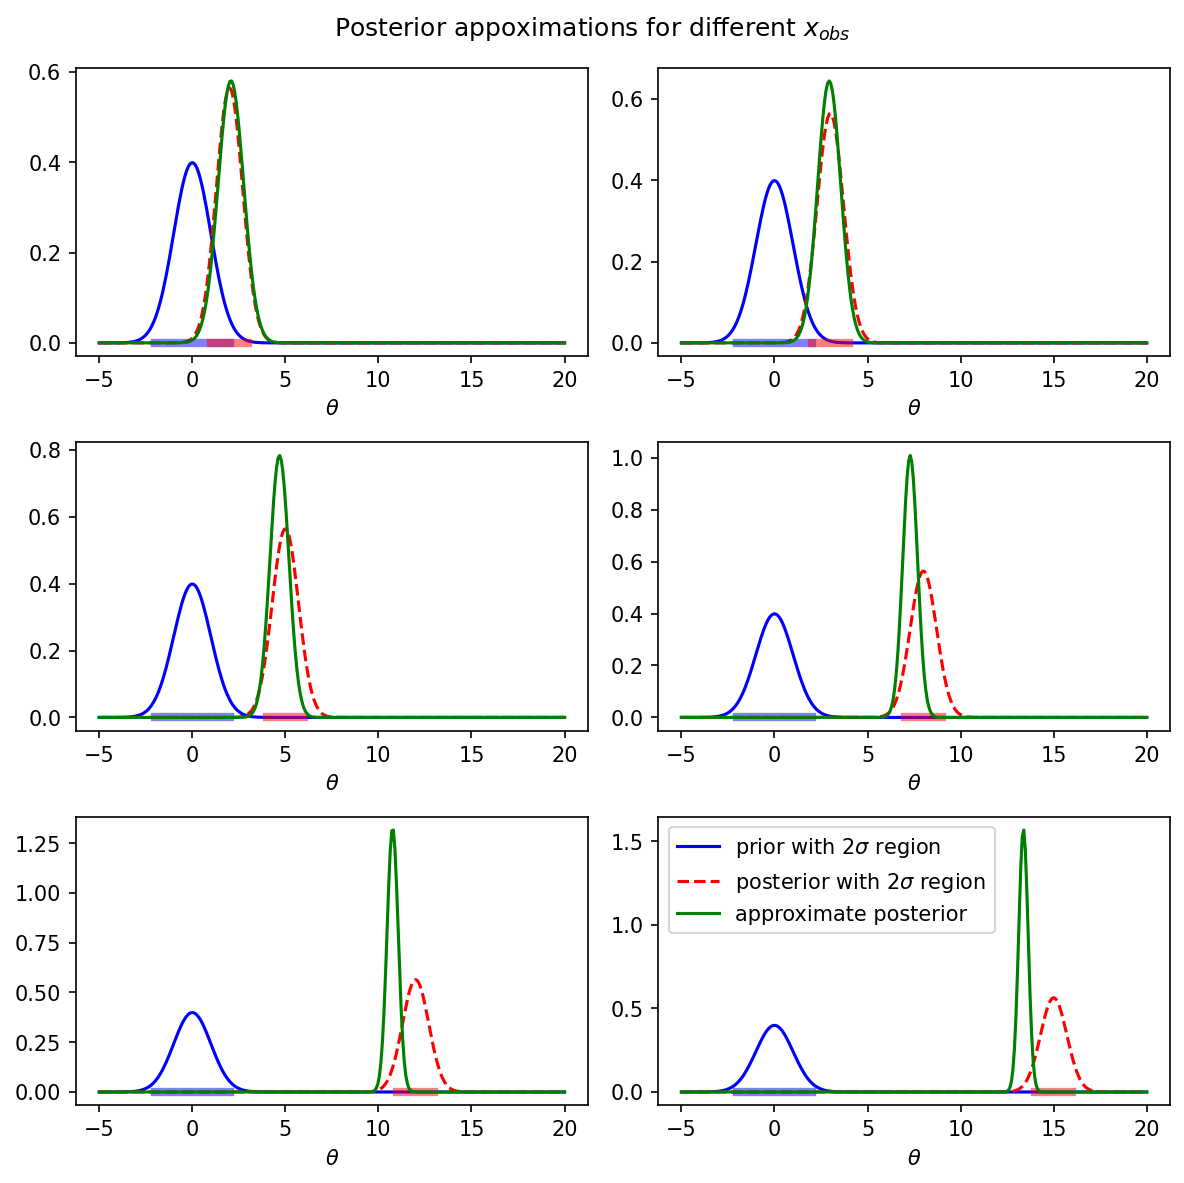

In [7]:
x_observed_values = [4,6,10,16,24,30]
theta_range = torch.linspace(-5,20,300).view(-1,1)
plot_approximate_posterior(approximate_posterior, prior_pdf, posterior_pdf, theta_range, x_observed_values, title=r"Posterior appoximations for different $x_{obs}$")

In [8]:
def approximate_posterior_quantiles_against_x(approximate_posterior, x_range):
    """
    Compute the 0.5%, 12.5%, 50%, 87.5%, 99.5% quantiles of the approximate posterior given x
    for each x in x_range. Returns a list of 5 lists.
    """
    quantiles = [[],[],[],[],[]]
    print(len(quantiles))
    theta_range_for_interpolation = torch.linspace(-100,100,2000).view(-1,1)
    for x in x_range:
        pdf_vals = approximate_posterior(theta_range_for_interpolation, x * torch.ones_like(theta_range_for_interpolation))
        cdf_vals = cumulative_trapezoid(pdf_vals.view(-1), theta_range_for_interpolation.view(-1), initial=0)
        cdf_vals /= cdf_vals[-1]   # normalize just in case
        InvCDF = interp1d(cdf_vals, theta_range_for_interpolation.view(-1))
        for i, q in enumerate([InvCDF(0.005), InvCDF(0.125), InvCDF(0.5), InvCDF(0.875), InvCDF(0.995)]):
            quantiles[i].append(q)
    return quantiles

def plot_approximate_posterior_quantiles_against_x(x_range, quantiles, title=None):
    """
    Plot contour-style plot of x against the 0.5%, 12.5%, 50%, 87.5%, 99.5% quantiles 
    of the approximate posterior given x for each x in x_range.

    quantiles should be computed using approximate_posterior_quantiles_against_x
    """
    fig, ax = plt.subplots(figsize=(10,5))
    colors = ["red", "blue", "black", "blue", "red"]
    color_shaded_region = ["red", "blue", "red"]
    levels = [0.005, 0.125, 0.875, 0.995]
    labels = ["99% of approximate popsterior mass", "75% of approximate popsterior mass", "median of approximate popsterior", None, None]
    labels_shaded_region = ["99% of posterior mass", "75% of posterior mass", None]

    # Compute true posterior quantiles
    true_quantiles = [
        scipy.stats.norm.ppf(levels[i], loc=x_range/2, scale=np.sqrt(1/2))
        for i in range(len(levels))
    ]

    # Shade regions between successive true posterior quantiles
    for i in range(len(levels) - 1):
        ax.fill_between(
            x_range,
            true_quantiles[i],
            true_quantiles[i+1],
            color=color_shaded_region[i],
            alpha=0.3,
            label=labels_shaded_region[i]
        )

    # Plot your approximate posterior quantile curves
    for i in range(len(quantiles)):
        ax.plot(x_range, quantiles[i], color=colors[i], linewidth=2, label = labels[i])

    ax.set_title(title)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$\theta$")

    plt.legend()
    plt.show()

5


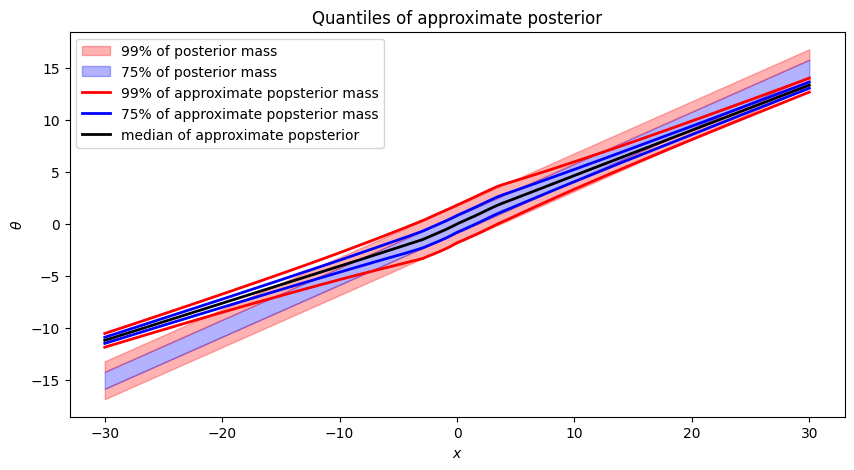

In [9]:
x_range = np.linspace(-30,30,2000)
quantiles = approximate_posterior_quantiles_against_x(approximate_posterior, x_range)
title = "Quantiles of approximate posterior"
plot_approximate_posterior_quantiles_against_x(x_range, quantiles, title=title)


### SBC on amortized (S)NPE-A

In [10]:
from sbc_utils.sbc_tools import sbc_ranks, plot_sbc_ecdf, plot_sbc_ecdf_diff, plot_sbc_histogram

In [14]:
N_iter = 1000
N_samp = 100
ranks = sbc_ranks(model, prior, posterior, N_iter=N_iter, N_samp=N_samp)

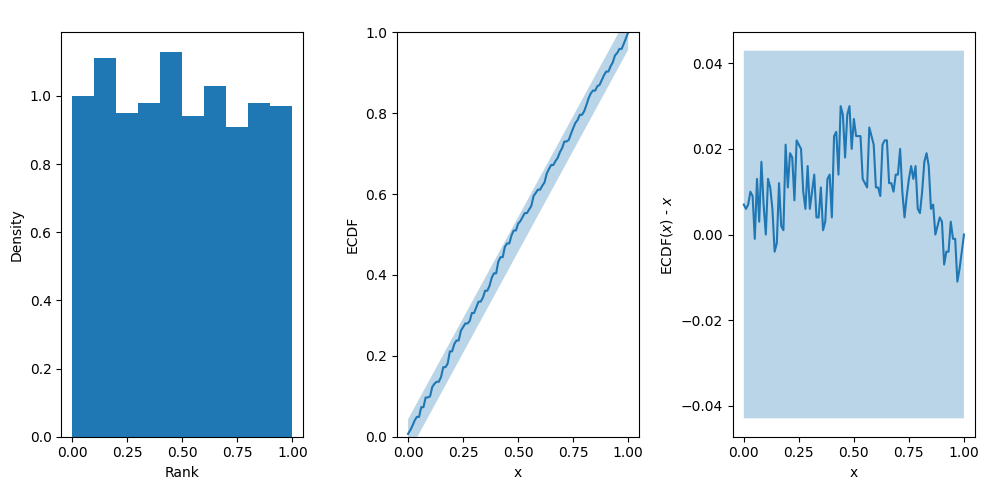

In [15]:
fig, ax = plt.subplots(figsize=(10,5), ncols=3)
plot_sbc_histogram(ranks, N_iter, N_samp, ax=ax[0], title=" ")
plot_sbc_ecdf(ranks, N_iter, N_samp, ax=ax[1], title=" ")
plot_sbc_ecdf_diff(ranks, N_iter, N_samp, ax=ax[2], title=" ")
plt.tight_layout()
plt.show()

# Sequential inference with SNPE-A

https://sbi.readthedocs.io/en/latest/how_to_guide/02_multiround_inference.html